In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
file_path = r"F:\DSBDA\DSBDAL CODES\StudentsPerformance.csv"

In [3]:
df = pd.read_csv(file_path)

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,NaN
1,female,group C,some college,standard,completed,69,90,88.0
2,female,group B,master's degree,standard,none,90,95,93.0
3,male,group A,associate's degree,free/reduced,none,47,57,44.0
4,male,group C,some college,standard,none,76,78,75.0


In [5]:
df.columns.tolist()

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [6]:

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  1
dtype: int64

In [7]:
numeric_cols = df.select_dtypes(include = np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [8]:
categorical_cols = df.select_dtypes(include = 'string').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
df.dtypes

gender                             str
race/ethnicity                     str
parental level of education        str
lunch                              str
test preparation course            str
math score                       int64
reading score                    int64
writing score                  float64
dtype: object

In [10]:
available_cols = [col for col in numeric_cols if col in df.columns]

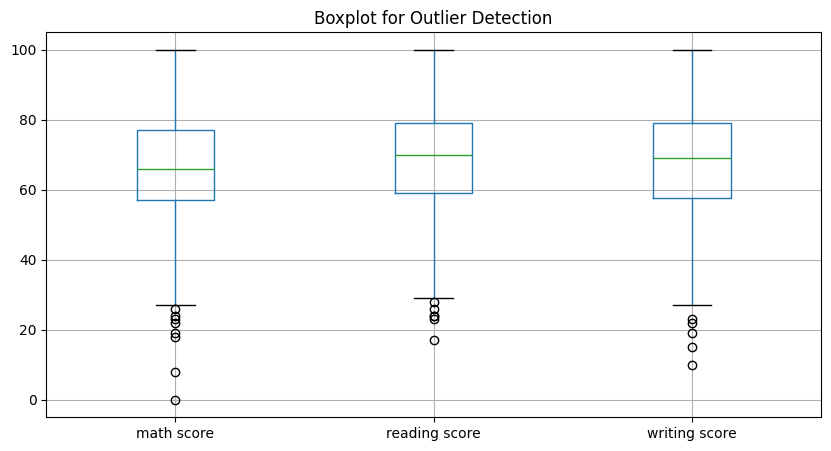


Dimensions before trimming outliers: (1000, 8)
Dimensions after trimming outliers: (988, 8)


In [11]:
if available_cols:
    plt.figure(figsize=(10, 5))
    df.boxplot(column=available_cols)
    plt.title("Boxplot for Outlier Detection")
    plt.show()

    Q1 = df[available_cols].quantile(0.25)
    Q3 = df[available_cols].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    condition = ~((df[available_cols] < lower) | (df[available_cols] > upper)).any(axis=1)
    new_df = df[condition].copy()

    print(f"\nDimensions before trimming outliers: {df.shape}")
    print(f"Dimensions after trimming outliers: {new_df.shape}")
else:
    new_df = df.copy()

In [12]:
#if 'club join year' in new_df.columns:
#    new_df['Duration'] = 2024 - new_df['club join year']
#    new_df[['club join year', 'Duration']].head()

In [13]:
if 'math score' in new_df.columns:
    new_df['log_math'] = np.log10(new_df['math score'] + 1)
    new_df[['math score', 'log_math']].head()

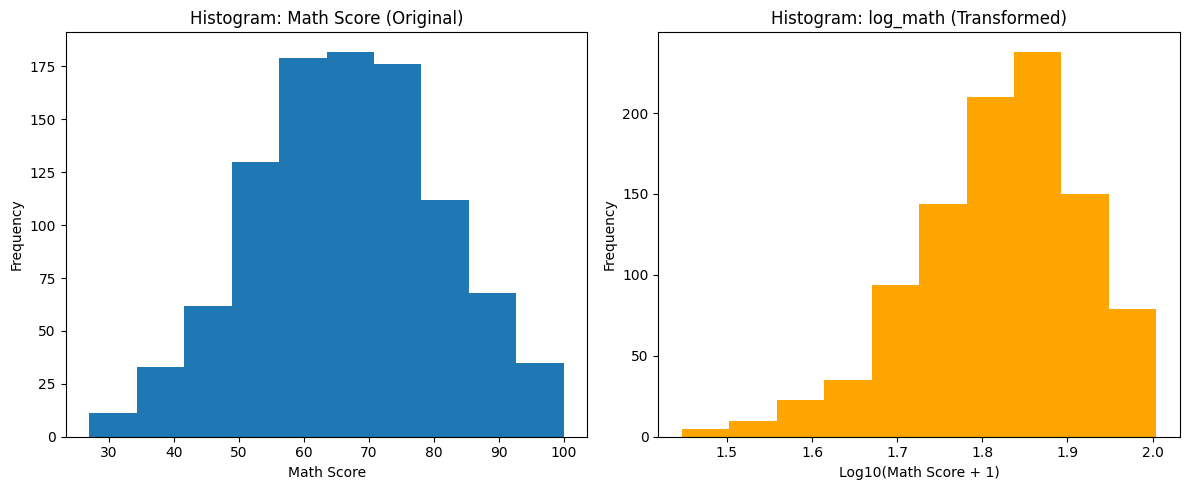

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
new_df['math score'].plot(kind='hist', title='Histogram: Math Score (Original)')
plt.xlabel("Math Score")

plt.subplot(1, 2, 2)
new_df['log_math'].plot(kind='hist', color='orange', title='Histogram: log_math (Transformed)')
plt.xlabel("Log10(Math Score + 1)")
plt.tight_layout()
plt.show()